# Publisher Analysis

This notebook analyzes publisher activity patterns and coverage characteristics from financial news data.

## Objectives
- Identify the most active publishers
- Characterize publisher coverage patterns
- Extract organizational domains from email addresses
- Analyze contribution patterns by organization

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


## Load and Explore Data

In [2]:
# Load the news data
file_path = '../Data/newsData/raw_analyst_ratings.csv'
df = pd.read_csv(file_path)

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1407328, 6)

Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

Data types:
Unnamed: 0     int64
headline      object
url           object
publisher     object
date          object
stock         object
dtype: object

Missing values:
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64


In [3]:
# Display sample data
print("Sample data:")
df.head()

Sample data:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
# Examine unique publishers
unique_publishers = df['publisher'].unique()
print(f"Total unique publishers: {len(unique_publishers)}")
print(f"\nSample publishers:")
for i, pub in enumerate(unique_publishers[:20]):
    print(f"{i+1:2d}. {pub}")

Total unique publishers: 1034

Sample publishers:
 1. Benzinga Insights
 2. Lisa Levin
 3. Vick Meyer
 4. vishwanath@benzinga.com
 5. Benzinga Newsdesk
 6. Tyree Gorges
 7. Luke J Jacobi
 8. Wayne Duggan
 9. Shivdeep Dhaliwal
10. luke@benzinga.com
11. Benzinga_Newsdesk
12. Spencer Israel
13. Joel Elconin
14. Charles Gross
15. Tanzeel Akhtar
16. Benzinga  Newsdesk
17. Brett Hershman
18. Hal Lindon
19. Shanthi Rexaline
20. Benzinga Newdesk


## Publisher Activity Analysis

In [5]:
# Count articles per publisher
publisher_counts = df['publisher'].value_counts().reset_index()
publisher_counts.columns = ['publisher', 'article_count']

# Calculate percentage of total articles
total_articles = len(df)
publisher_counts['percentage'] = (publisher_counts['article_count'] / total_articles) * 100

print(f"Top 20 most active publishers:")
print(publisher_counts.head(20).to_string(index=False))

Top 20 most active publishers:
        publisher  article_count  percentage
    Paul Quintaro         228373   16.227418
       Lisa Levin         186979   13.286100
Benzinga Newsdesk         150484   10.692888
    Charles Gross          96732    6.873451
    Monica Gerson          82380    5.853646
     Eddie Staley          57254    4.068277
       Hal Lindon          49047    3.485115
    ETF Professor          28489    2.024333
       Juan Lopez          28438    2.020709
   Benzinga Staff          28114    1.997686
       Vick Meyer          24826    1.764052
        webmaster          20313    1.443374
Benzinga_Newsdesk          19410    1.379209
            Zacks          19390    1.377788
   Jayson Derrick          19050    1.353629
    Allie Wickman          18317    1.301544
 Shanthi Rexaline          16640    1.182383
      Craig Jones          16221    1.152610
     Wayne Duggan          12897    0.916417
       Nelson Hem          12590    0.894603


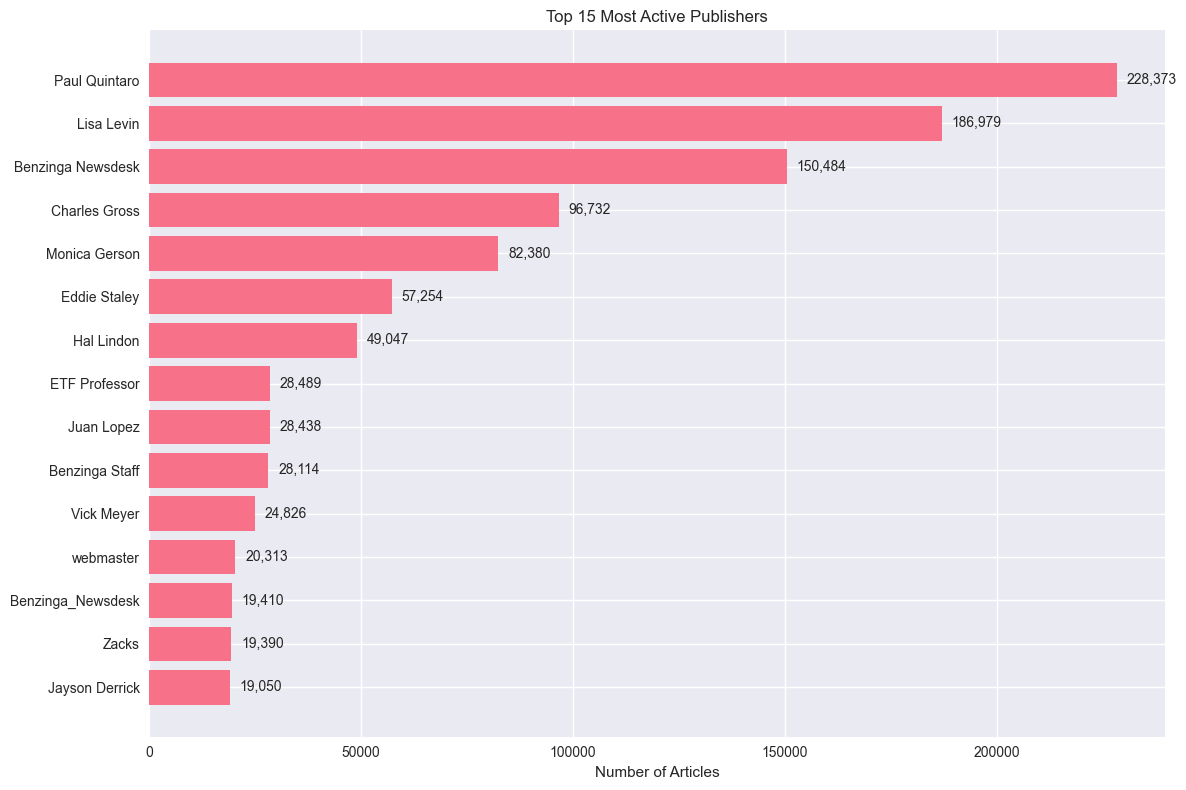

In [6]:
# Create visualization for top publishers
plt.figure(figsize=(12, 8))
top_publishers = publisher_counts.head(15)

bars = plt.barh(range(len(top_publishers)), top_publishers['article_count'])
plt.yticks(range(len(top_publishers)), top_publishers['publisher'])
plt.xlabel('Number of Articles')
plt.title('Top 15 Most Active Publishers')
plt.gca().invert_yaxis()

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + max(top_publishers['article_count'])*0.01, bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', ha='left', va='center')

plt.tight_layout()
plt.show()

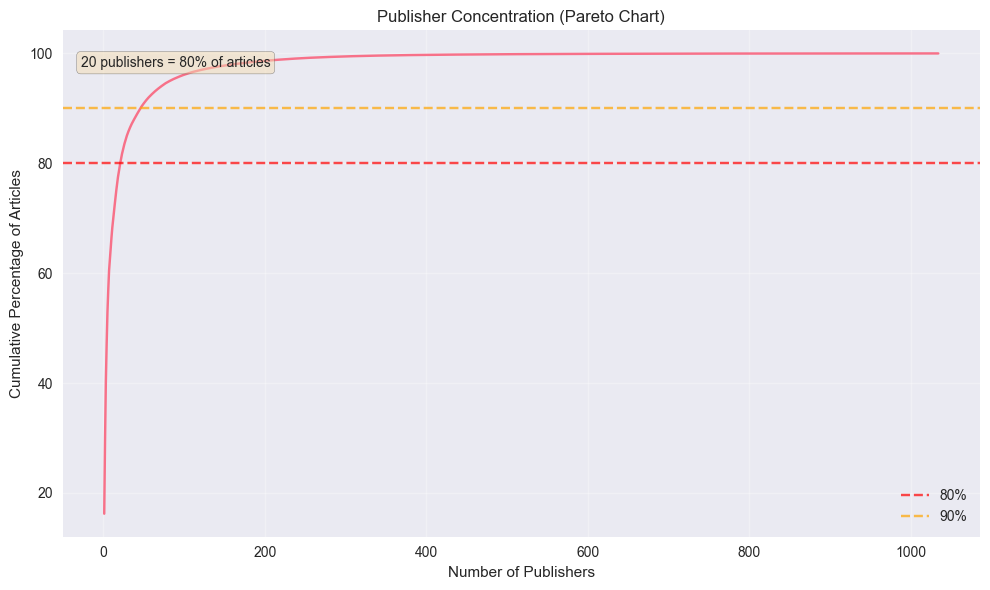

In [7]:
# Analyze publisher concentration
plt.figure(figsize=(10, 6))

# Cumulative distribution
cumulative_pct = publisher_counts['percentage'].cumsum()
plt.plot(range(1, len(cumulative_pct) + 1), cumulative_pct)
plt.xlabel('Number of Publishers')
plt.ylabel('Cumulative Percentage of Articles')
plt.title('Publisher Concentration (Pareto Chart)')
plt.grid(True, alpha=0.3)

# Add reference lines
plt.axhline(y=80, color='r', linestyle='--', alpha=0.7, label='80%')
plt.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90%')
plt.legend()

# Find how many publishers account for 80% of articles
publishers_80_pct = publisher_counts[cumulative_pct <= 80].shape[0]
publishers_90_pct = publisher_counts[cumulative_pct <= 90].shape[0]

plt.text(0.02, 0.95, f'{publishers_80_pct} publishers = 80% of articles', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Email Domain Extraction and Organizational Analysis

In [8]:
def extract_email_domains(publisher_list):
    """
    Extract email domains from publisher names.
    Returns a dictionary mapping publisher names to their domains.
    """
    email_pattern = r'\b[A-Za-z0-9._%+-]+@([A-Za-z0-9.-]+\.[A-Z|a-z]{2,})\b'
    domain_mapping = {}
    
    for publisher in publisher_list:
        if pd.isna(publisher):
            continue
            
        # Find email addresses in the publisher string
        matches = re.findall(email_pattern, str(publisher))
        if matches:
            # Take the first domain found
            domain_mapping[publisher] = matches[0].lower()
    
    return domain_mapping

# Extract domains from all publishers
domain_mapping = extract_email_domains(df['publisher'].unique())

print(f"Found {len(domain_mapping)} publishers with email addresses")
print(f"\nSample email domains:")
for i, (publisher, domain) in enumerate(list(domain_mapping.items())[:10]):
    print(f"{i+1:2d}. {publisher} -> {domain}")

Found 18 publishers with email addresses

Sample email domains:
 1. vishwanath@benzinga.com -> benzinga.com
 2. luke@benzinga.com -> benzinga.com
 3. vivek.proactive@gmail.com -> gmail.com
 4. bret.kenwell@benzinga.com -> benzinga.com
 5. richa28dhand@gmail.com -> gmail.com
 6. Andy@andyswan.com -> andyswan.com
 7. kiana@investdiva.com -> investdiva.com
 8. adam@eosdetroit.io -> eosdetroit.io
 9. andrew@tothetick.com -> tothetick.com
10. newsdesk+benzingastaffwriter3@benzinga.com -> benzinga.com


In [9]:
# Analyze organizational domains
domain_counts = Counter(domain_mapping.values())
domain_df = pd.DataFrame(list(domain_counts.items()), columns=['domain', 'publisher_count'])
domain_df = domain_df.sort_values('publisher_count', ascending=False)

print(f"Top 20 organizational domains:")
print(domain_df.head(20).to_string(index=False))

Top 20 organizational domains:
                domain  publisher_count
          benzinga.com                9
             gmail.com                3
          andyswan.com                1
        investdiva.com                1
         eosdetroit.io                1
         tothetick.com                1
forextraininggroup.com                1
       stockmetrix.net                1


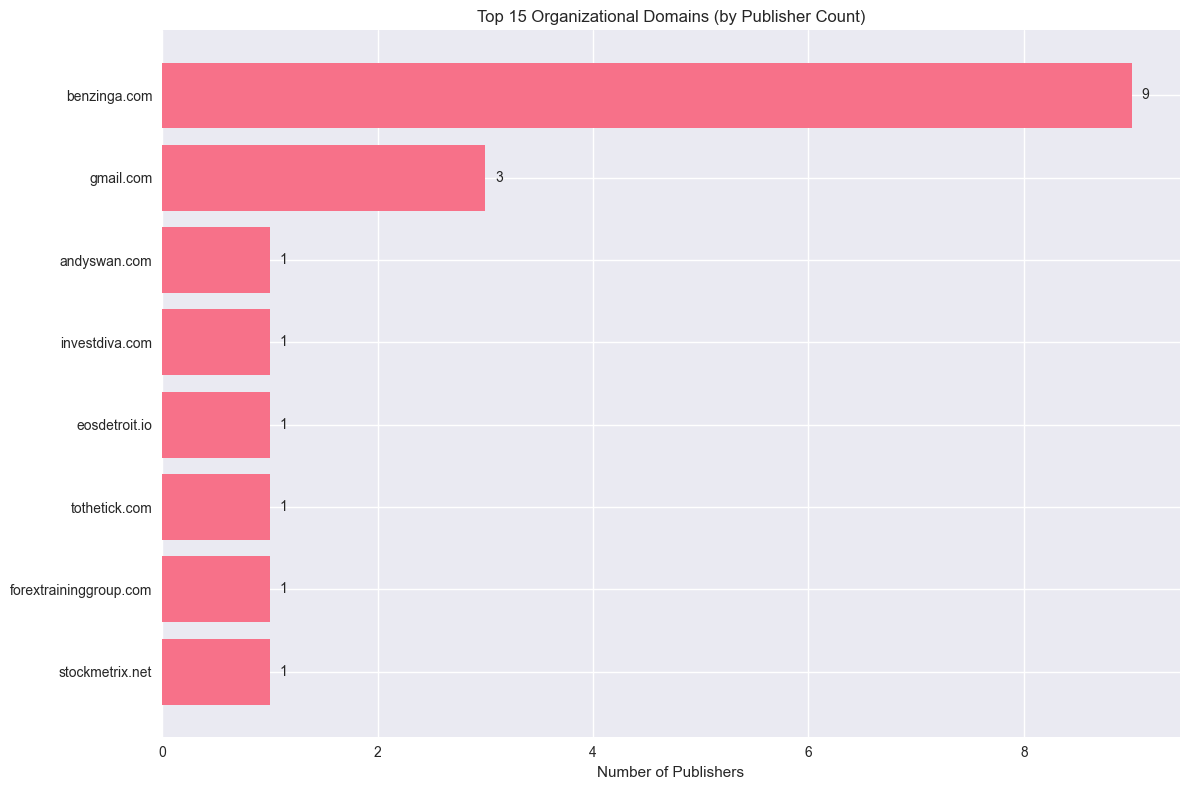

In [10]:
# Create visualization for top domains
plt.figure(figsize=(12, 8))
top_domains = domain_df.head(15)

bars = plt.barh(range(len(top_domains)), top_domains['publisher_count'])
plt.yticks(range(len(top_domains)), top_domains['domain'])
plt.xlabel('Number of Publishers')
plt.title('Top 15 Organizational Domains (by Publisher Count)')
plt.gca().invert_yaxis()

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + max(top_domains['publisher_count'])*0.01, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', ha='left', va='center')

plt.tight_layout()
plt.show()

## Publisher Coverage Patterns Analysis

In [14]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()

# Analyze temporal patterns for top publishers
top_10_publishers = publisher_counts.head(10)['publisher'].tolist()
top_publisher_data = df[df['publisher'].isin(top_10_publishers)]

print(f"Analyzing temporal patterns for top 10 publishers...")
print(f"Articles from top 10 publishers: {len(top_publisher_data):,}")

Analyzing temporal patterns for top 10 publishers...
Articles from top 10 publishers: 936,290


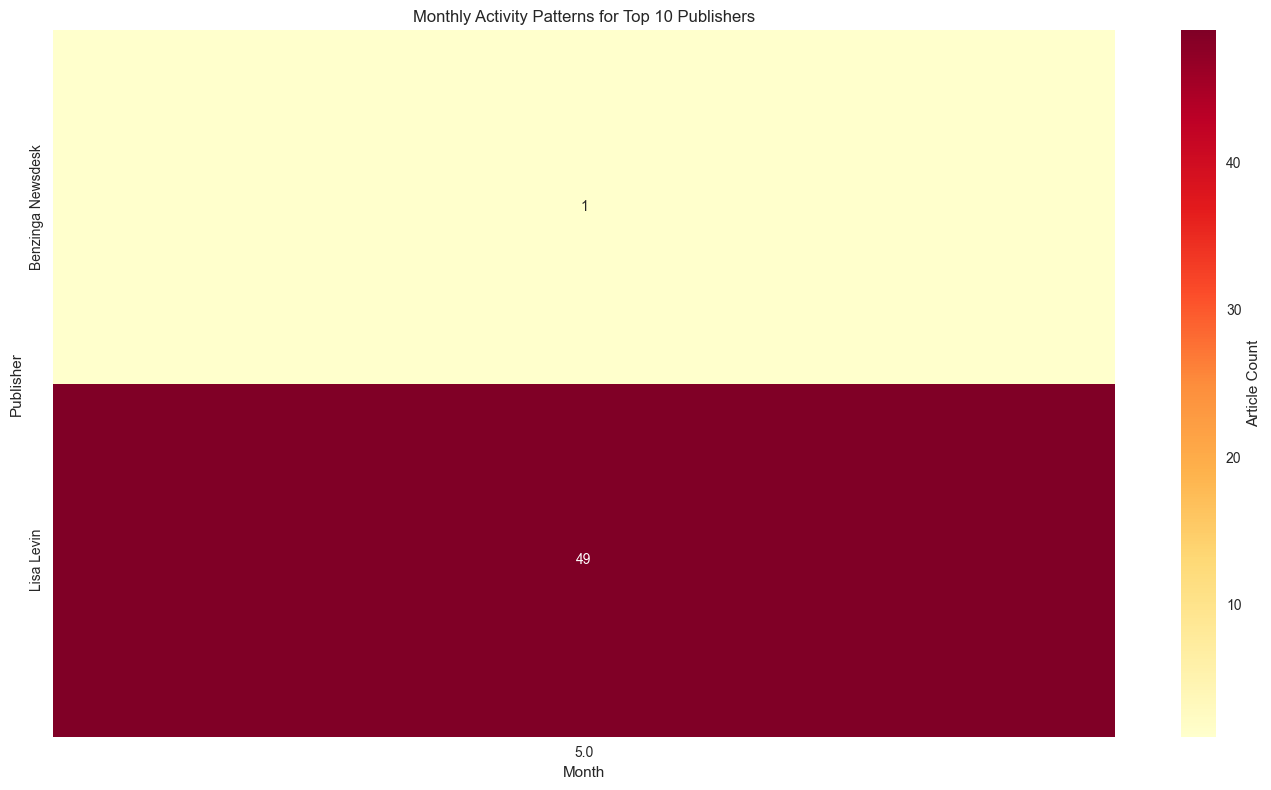

In [15]:
# Monthly activity patterns for top publishers
monthly_activity = top_publisher_data.groupby(['publisher', 'month']).size().reset_index(name='article_count')
monthly_pivot = monthly_activity.pivot(index='publisher', columns='month', values='article_count').fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(monthly_pivot, annot=True, fmt='g', cmap='YlOrRd', cbar_kws={'label': 'Article Count'})
plt.title('Monthly Activity Patterns for Top 10 Publishers')
plt.xlabel('Month')
plt.ylabel('Publisher')
plt.tight_layout()
plt.show()

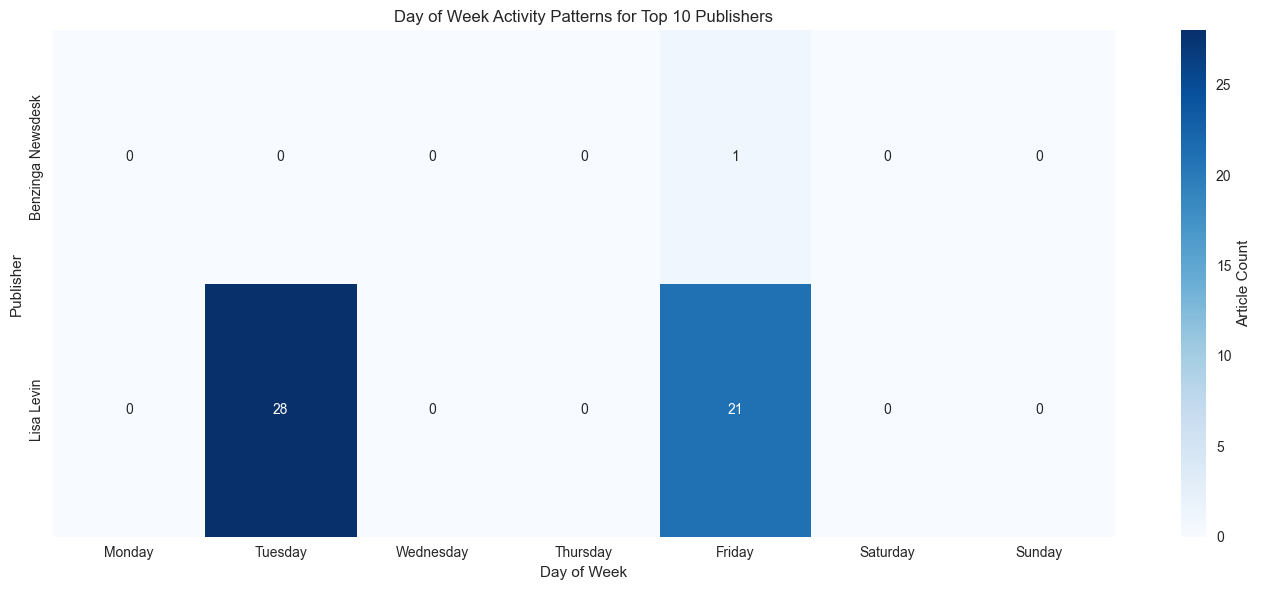

In [16]:
# Day of week patterns
dow_activity = top_publisher_data.groupby(['publisher', 'day_of_week']).size().reset_index(name='article_count')
dow_pivot = dow_activity.pivot(index='publisher', columns='day_of_week', values='article_count').fillna(0)

# Reorder columns to be in chronological order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_pivot = dow_pivot.reindex(columns=day_order, fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(dow_pivot, annot=True, fmt='g', cmap='Blues', cbar_kws={'label': 'Article Count'})
plt.title('Day of Week Activity Patterns for Top 10 Publishers')
plt.xlabel('Day of Week')
plt.ylabel('Publisher')
plt.tight_layout()
plt.show()

## Stock Coverage Analysis

In [17]:
# Analyze stock coverage by publishers
stock_coverage = df.groupby('publisher')['stock'].nunique().reset_index(name='unique_stocks_covered')
stock_coverage = stock_coverage.merge(publisher_counts, on='publisher')
stock_coverage = stock_coverage.sort_values('unique_stocks_covered', ascending=False)

print(f"Top 20 publishers by unique stock coverage:")
print(stock_coverage[['publisher', 'unique_stocks_covered', 'article_count']].head(20).to_string(index=False))

Top 20 publishers by unique stock coverage:
        publisher  unique_stocks_covered  article_count
    Paul Quintaro                   4703         228373
       Lisa Levin                   4640         186979
       Hal Lindon                   4474          49047
     Eddie Staley                   4466          57254
    Charles Gross                   4181          96732
Benzinga Newsdesk                   4049         150484
    Monica Gerson                   4012          82380
   Benzinga Staff                   3233          28114
    Allie Wickman                   3009          18317
Benzinga_Newsdesk                   2924          19410
       Juan Lopez                   2883          28438
        webmaster                   2618          20313
   Dwight Einhorn                   2401          12226
    David Johnson                   2338           8749
       Vick Meyer                   2287          24826
  Matthew Kennedy                   2238           8167
   J

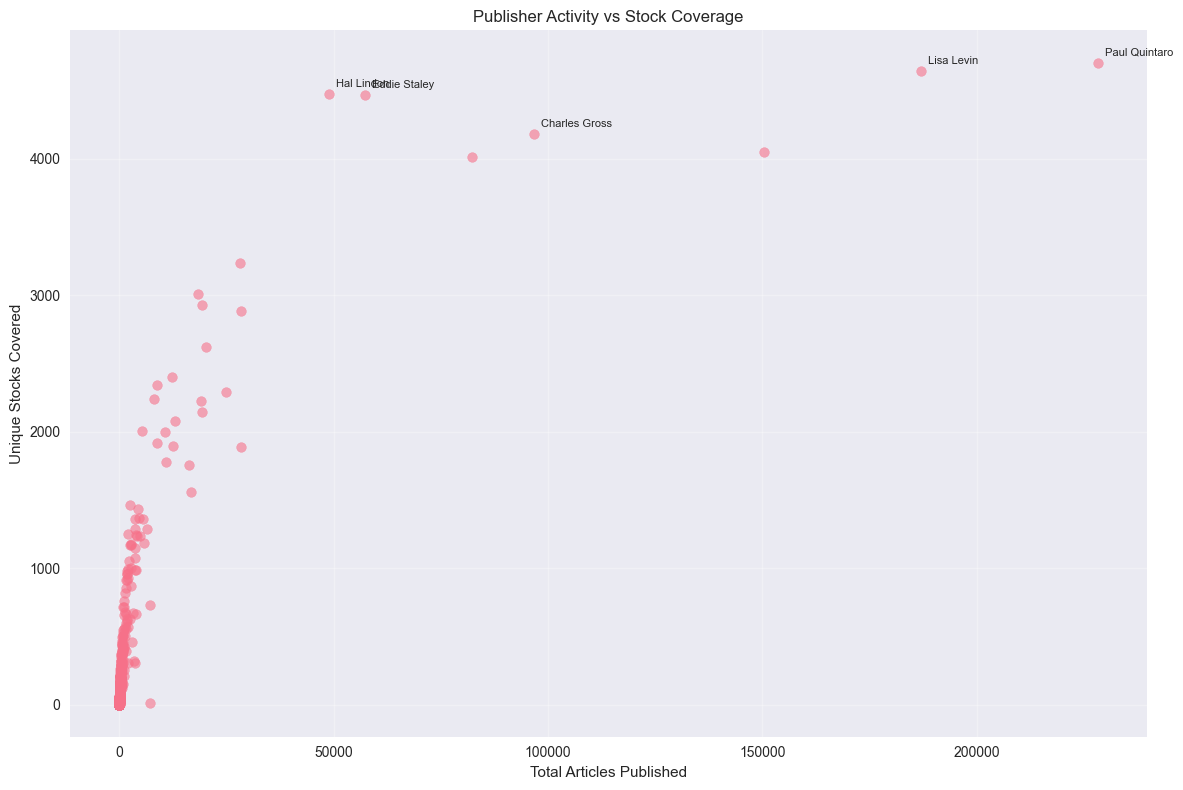

In [18]:
# Create scatter plot of article count vs stock coverage
plt.figure(figsize=(12, 8))
plt.scatter(stock_coverage['article_count'], stock_coverage['unique_stocks_covered'], alpha=0.6)

# Highlight top publishers
top_5_coverage = stock_coverage.head(5)
for _, row in top_5_coverage.iterrows():
    plt.annotate(row['publisher'], 
                 (row['article_count'], row['unique_stocks_covered']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel('Total Articles Published')
plt.ylabel('Unique Stocks Covered')
plt.title('Publisher Activity vs Stock Coverage')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Publisher Classification and Insights

In [19]:
# Classify publishers based on their characteristics
def classify_publisher(row):
    """
    Classify publishers into categories based on their activity patterns.
    """
    article_count = row['article_count']
    stock_coverage = row['unique_stocks_covered']
    
    # Calculate coverage ratio (stocks per article)
    coverage_ratio = stock_coverage / article_count if article_count > 0 else 0
    
    if article_count >= 1000:
        if coverage_ratio >= 0.5:
            return 'High Volume - Broad Coverage'
        else:
            return 'High Volume - Focused Coverage'
    elif article_count >= 100:
        if coverage_ratio >= 0.5:
            return 'Medium Volume - Broad Coverage'
        else:
            return 'Medium Volume - Focused Coverage'
    else:
        if coverage_ratio >= 0.5:
            return 'Low Volume - Broad Coverage'
        else:
            return 'Low Volume - Focused Coverage'

# Apply classification
stock_coverage['coverage_ratio'] = stock_coverage['unique_stocks_covered'] / stock_coverage['article_count']
stock_coverage['publisher_type'] = stock_coverage.apply(classify_publisher, axis=1)

# Display classification results
classification_summary = stock_coverage['publisher_type'].value_counts().reset_index()
classification_summary.columns = ['publisher_type', 'count']

print("Publisher Classification:")
print(classification_summary.to_string(index=False))

Publisher Classification:
                  publisher_type  count
     Low Volume - Broad Coverage    743
  Medium Volume - Broad Coverage    131
  High Volume - Focused Coverage     72
Medium Volume - Focused Coverage     39
   Low Volume - Focused Coverage     36
    High Volume - Broad Coverage     13


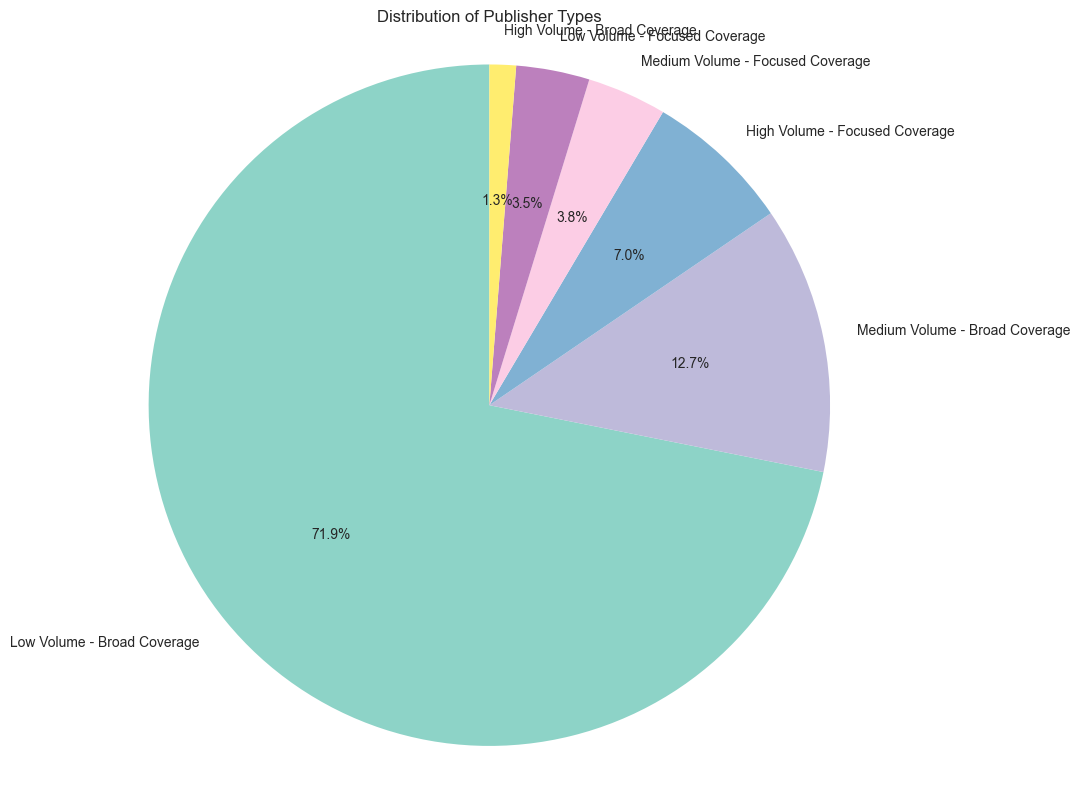

In [20]:
# Create pie chart of publisher types
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(classification_summary)))
plt.pie(classification_summary['count'], labels=classification_summary['publisher_type'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribution of Publisher Types')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Summary and Key Insights

In [21]:
# Generate comprehensive summary
print("=" * 60)
print("PUBLISHER ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nDataset Overview:")
print(f"  - Total articles: {len(df):,}")
print(f"  - Total unique publishers: {len(df['publisher'].unique()):,}")
print(f"  - Total unique stocks covered: {df['stock'].nunique():,}")
print(f"  - Date range: {df['date'].min().date()} to {df['date'].max().date()}")

print(f"\nTop Publishers:")
for i, row in publisher_counts.head(5).iterrows():
    print(f"  {i+1}. {row['publisher']}: {row['article_count']:,} articles ({row['percentage']:.1f}%)")

print(f"\nMarket Concentration:")
print(f"  - Top {publishers_80_pct} publishers account for 80% of articles")
print(f"  - Top {publishers_90_pct} publishers account for 90% of articles")

print(f"\nOrganizational Analysis:")
print(f"  - Publishers with email addresses: {len(domain_mapping)}")
print(f"  - Unique organizational domains: {len(domain_counts)}")
if len(domain_counts) > 0:
    print(f"  - Top domain: {domain_df.iloc[0]['domain']} ({domain_df.iloc[0]['publisher_count']} publishers)")

print(f"\nCoverage Patterns:")
avg_stocks_per_publisher = stock_coverage['unique_stocks_covered'].mean()
print(f"  - Average stocks covered per publisher: {avg_stocks_per_publisher:.1f}")
print(f"  - Most diverse publisher: {stock_coverage.iloc[0]['publisher']} ({stock_coverage.iloc[0]['unique_stocks_covered']} stocks)")

print("\n" + "=" * 60)

PUBLISHER ANALYSIS SUMMARY

Dataset Overview:
  - Total articles: 1,407,328
  - Total unique publishers: 1,034
  - Total unique stocks covered: 6,204
  - Date range: 2020-05-22 to 2020-06-05

Top Publishers:
  1. Paul Quintaro: 228,373 articles (16.2%)
  2. Lisa Levin: 186,979 articles (13.3%)
  3. Benzinga Newsdesk: 150,484 articles (10.7%)
  4. Charles Gross: 96,732 articles (6.9%)
  5. Monica Gerson: 82,380 articles (5.9%)

Market Concentration:
  - Top 20 publishers account for 80% of articles
  - Top 45 publishers account for 90% of articles

Organizational Analysis:
  - Publishers with email addresses: 18
  - Unique organizational domains: 8
  - Top domain: benzinga.com (9 publishers)

Coverage Patterns:
  - Average stocks covered per publisher: 160.5
  - Most diverse publisher: Paul Quintaro (4703 stocks)



## Export Results

In [22]:
# Export key results to CSV files
output_dir = '../Data/publisher_analysis_results'
import os
os.makedirs(output_dir, exist_ok=True)

# Export publisher rankings
publisher_counts.to_csv(f'{output_dir}/publisher_rankings.csv', index=False)

# Export stock coverage analysis
stock_coverage.to_csv(f'{output_dir}/stock_coverage_analysis.csv', index=False)

# Export domain analysis
domain_df.to_csv(f'{output_dir}/organizational_domains.csv', index=False)

# Export publisher classifications
stock_coverage[['publisher', 'article_count', 'unique_stocks_covered', 'coverage_ratio', 'publisher_type']].to_csv(
    f'{output_dir}/publisher_classifications.csv', index=False)

print(f"Results exported to {output_dir}/")
print("Files created:")
print("  - publisher_rankings.csv")
print("  - stock_coverage_analysis.csv")
print("  - organizational_domains.csv")
print("  - publisher_classifications.csv")

Results exported to ../Data/publisher_analysis_results/
Files created:
  - publisher_rankings.csv
  - stock_coverage_analysis.csv
  - organizational_domains.csv
  - publisher_classifications.csv
